# DACON Action Decision (236694) — Data Statistics & Hint Probing

Computes descriptive statistics on `train.jsonl` (70k) and probes whether the target
`action` is **trivially determined** by any single feature (a shortcut/leak) before
we invest in real modeling.

**Sections**
1. Load data
2. Label distribution
3. `session_meta` / `workspace` distributions
4. `history` structure
5. **Hint probes** — single-feature rules & how much accuracy they buy
6. Summary

> Note: the public `test.jsonl` (5 rows) is a copy of train rows, so all analysis
> here is on `train.jsonl`. Build a proper validation split from train for scoring.

In [1]:
import json, csv, re
from collections import Counter, defaultdict
from pathlib import Path
import pandas as pd
import numpy as np

DATA = Path("..") / "data"          # notebook lives in analysis/
TRAIN = DATA / "train.jsonl"
LABELS = DATA / "train_labels.csv"

# labels: id -> action
labels = {}
with open(LABELS, encoding="utf-8") as f:
    for row in csv.DictReader(f):
        labels[row["id"]] = row["action"]

# rows: list of sample dicts
rows = []
with open(TRAIN, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

y = [labels[r["id"]] for r in rows]
N = len(rows)
CLASSES = sorted(set(y))
print(f"rows={N}  labels={len(labels)}  classes={len(CLASSES)}")
print("classes:", CLASSES)

rows=70000  labels=70000  classes=14
classes: ['apply_patch', 'ask_user', 'edit_file', 'glob_pattern', 'grep_search', 'lint_or_typecheck', 'list_directory', 'plan_task', 'read_file', 'respond_only', 'run_bash', 'run_tests', 'web_search', 'write_file']


## 2. Label distribution

Class frequencies + the **majority-class baseline** (the floor any model must beat).

In [2]:
base = Counter(y)
dist = (pd.DataFrame({"action": list(base.keys()), "count": list(base.values())})
        .sort_values("count", ascending=False)
        .assign(pct=lambda d: (d["count"] / N * 100).round(2))
        .reset_index(drop=True))
maj_action, maj_n = base.most_common(1)[0]
print(f"majority-class baseline: predict '{maj_action}' -> acc = {maj_n/N:.4f}")
print(f"random (uniform) baseline: {1/len(CLASSES):.4f}")
dist

majority-class baseline: predict 'edit_file' -> acc = 0.1596
random (uniform) baseline: 0.0714


,action,count,pct
0,edit_file,11171,15.96
1,grep_search,9912,14.16
2,read_file,9257,13.22
3,glob_pattern,5284,7.55
4,respond_only,5178,7.40
5,run_bash,5068,7.24
6,apply_patch,4823,6.89
7,run_tests,4561,6.52
8,list_directory,4329,6.18
9,ask_user,2701,3.86


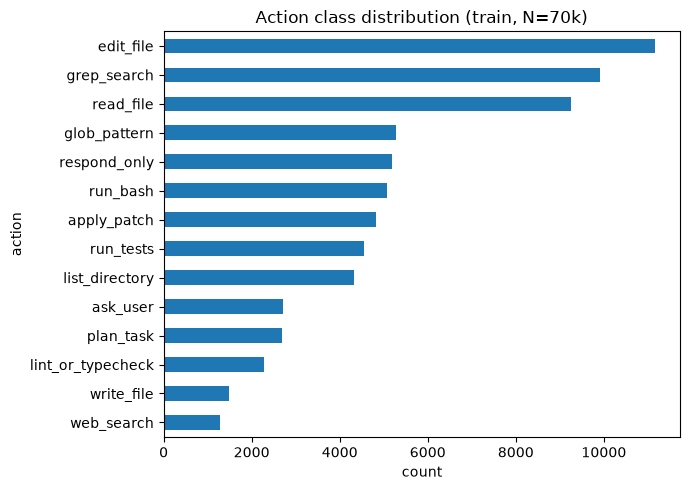

In [3]:
import matplotlib.pyplot as plt
ax = dist.set_index("action")["count"].plot(kind="barh", figsize=(7, 5))
ax.invert_yaxis(); ax.set_title("Action class distribution (train, N=70k)"); ax.set_xlabel("count")
plt.tight_layout(); plt.show()

## 3. `session_meta` / `workspace` distributions

Flatten scalar meta fields into a DataFrame for quick description and to check whether
any category is strongly skewed toward a single action.

In [4]:
def flatten(r):
    sm = r["session_meta"]; ws = sm["workspace"]
    return {
        "action": labels[r["id"]],
        "user_tier": sm["user_tier"],
        "language_pref": sm["language_pref"],
        "budget_tokens_remaining": sm["budget_tokens_remaining"],
        "turn_index": sm["turn_index"],
        "elapsed_session_sec": sm["elapsed_session_sec"],
        "loc": ws["loc"],
        "git_dirty": ws["git_dirty"],
        "last_ci_status": ws["last_ci_status"],
        "n_open_files": len(ws["open_files"]),
        "n_langs": len(ws["language_mix"]),
        "top_lang": max(ws["language_mix"], key=ws["language_mix"].get) if ws["language_mix"] else None,
        "hist_len": len(r["history"]),
        "prompt_len": len(r.get("current_prompt") or ""),
    }

df = pd.DataFrame(flatten(r) for r in rows)
print(df.shape)
df.head()

(70000, 14)


,action,user_tier,language_pref,budget_tokens_remaining,turn_index,elapsed_session_sec,loc,git_dirty,last_ci_status,n_open_files,n_langs,top_lang,hist_len,prompt_len
0,run_tests,enterprise,en,131818,8,720,15326,True,passed,2,4,py,12,84
1,read_file,pro,en,126987,1,225,8355,True,none,0,4,ts,0,82
2,web_search,free,ko,8894,6,491,25482,True,failed,1,4,ts,10,90
3,respond_only,pro,mixed,157481,12,803,56106,True,passed,1,4,java,12,31
4,edit_file,enterprise,ko,191791,1,241,49385,False,passed,0,4,vue,0,58


In [5]:
# categorical value counts
for col in ["user_tier", "language_pref", "last_ci_status", "git_dirty"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string())
    print()

# numeric summary
df[["budget_tokens_remaining","turn_index","elapsed_session_sec","loc",
    "n_open_files","n_langs","hist_len","prompt_len"]].describe().round(1)

--- user_tier ---
user_tier
pro           37733
free          20948
enterprise    11319

--- language_pref ---
language_pref
ko       45028
en       17802
mixed     7170

--- last_ci_status ---
last_ci_status
passed    28035
failed    22623
none      19342

--- git_dirty ---
git_dirty
True     53701
False    16299



,budget_tokens_remaining,turn_index,elapsed_session_sec,loc,n_open_files,n_langs,hist_len,prompt_len
count,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0
mean,92438.6,5.2,510.9,22702.0,0.8,3.9,6.9,61.0
std,51482.5,3.5,245.8,18500.1,0.6,0.5,4.4,32.6
min,55.0,1.0,30.0,206.0,0.0,3.0,0.0,2.0
25%,43753.0,2.0,327.0,9339.8,0.0,4.0,2.0,37.0
50%,94450.0,5.0,498.0,18059.0,1.0,4.0,8.0,56.0
75%,137137.8,7.0,669.0,30578.0,1.0,4.0,12.0,77.0
max,199741.0,18.0,1530.0,90000.0,5.0,5.0,12.0,346.0


In [6]:
# For each categorical feature value: does it concentrate on one action?
# purity = P(most-common action | feature value). High purity => a hint.
def purity_table(col):
    out = []
    for val, sub in df.groupby(col, dropna=False):
        c = Counter(sub["action"])
        top, n = c.most_common(1)[0]
        out.append({col: val, "n": len(sub), "top_action": top, "purity": round(n/len(sub), 3)})
    return pd.DataFrame(out).sort_values("purity", ascending=False)

for col in ["user_tier", "language_pref", "last_ci_status", "top_lang"]:
    print(f"===== {col} =====")
    print(purity_table(col).to_string(index=False))
    print()

===== user_tier =====
 user_tier     n top_action  purity
      free 20948  edit_file   0.164
enterprise 11319  edit_file   0.159
       pro 37733  edit_file   0.158

===== language_pref =====
language_pref     n top_action  purity
           ko 45028  edit_file   0.161
        mixed  7170  edit_file   0.161
           en 17802  edit_file   0.156

===== last_ci_status =====
last_ci_status     n  top_action  purity
        failed 22623   edit_file   0.180
        passed 28035   edit_file   0.152
          none 19342 grep_search   0.151

===== top_lang =====
top_lang     n  top_action  purity
    yaml  4328 grep_search   0.196
     tsx  5841   edit_file   0.169
     vue  6457   edit_file   0.165
      ts  5752   edit_file   0.163
      go  4648   edit_file   0.161
    java  7196   edit_file   0.161
      rs  7881   edit_file   0.160
      py 27897   edit_file   0.155



## 4. `history` structure

Length distribution and the frequency of each action *inside* history (a different
distribution from the target, since the target is the *next* action).

In [7]:
print("history length distribution:")
print(df["hist_len"].value_counts().sort_index().to_string())
print(f"\nfrac with empty history (turn 1): {(df['hist_len']==0).mean():.3f}")

# action frequency inside history
hist_actions = Counter()
for r in rows:
    for t in r["history"]:
        if t.get("role") == "assistant_action":
            hist_actions[t["name"]] += 1
print("\naction frequency INSIDE history:")
print(pd.Series(hist_actions).sort_values(ascending=False).to_string())

history length distribution:
hist_len
0      9000
2      8797
4      8446
6      8001
8      7526
10     6644
12    21586

frac with empty history (turn 1): 0.129



action frequency INSIDE history:
edit_file            40547
grep_search          37829
read_file            35982
run_bash             20342
list_directory       19923
glob_pattern         19409
apply_patch          14670
run_tests            14476
plan_task            11727
ask_user              9621
write_file            6940
lint_or_typecheck     6910
web_search            4156


## 5. Hint probes — is the answer a shortcut?

Each probe is a **single-feature rule**. We report accuracy over all 70k rows. If any
rule scores far above the 0.16 majority baseline, that feature is an "obvious hint".

Probes ranked by how directly they could leak the answer:
- **H1** last history action → next action (transition determinism)
- **H2** `current_prompt` keyword rules → action
- **H3** `session_meta` shortcuts (CI status, open_files, history-empty)
- **H4** `current_prompt` memorization (exact-match oracle — upper bound on prompt leak)

> Rules learned on all train data are **optimistic** (train-oracle upper bounds).
> They answer "is the signal there?", not "what will generalize".

In [8]:
def score(name, preds, verbose=True):
    """preds: list len N of predicted label or None (None = abstain, counted as wrong)."""
    correct = sum(1 for p, t in zip(preds, y) if p == t)
    covered = sum(1 for p in preds if p is not None)
    acc = correct / N
    cov_acc = correct / covered if covered else 0.0
    if verbose:
        print(f"[{name}]  acc={acc:.4f}  coverage={covered/N:.3f}  acc|covered={cov_acc:.4f}")
    return acc

MAJ = maj_n / N
print(f"baselines -> majority={MAJ:.4f}  uniform={1/len(CLASSES):.4f}")

baselines -> majority=0.1596  uniform=0.0714


In [9]:
# ---- H1: last history action -> next action ----
def last_action(r):
    for t in reversed(r["history"]):
        if t.get("role") == "assistant_action":
            return t["name"]
    return None   # empty history / turn 1

trans = defaultdict(Counter)
for r, t in zip(rows, y):
    trans[last_action(r)][t] += 1
trans_map = {k: c.most_common(1)[0][0] for k, c in trans.items()}
preds_h1 = [trans_map[last_action(r)] for r in rows]
acc_h1 = score("H1 last_action -> argmax next", preds_h1)

print("\nP(argmax next | last_action)  — how deterministic is the transition:")
tbl = []
for k, c in trans.items():
    tot = sum(c.values()); top, n = c.most_common(1)[0]
    tbl.append({"last_action": k, "n": tot, "argmax_next": top, "P": round(n/tot, 3)})
print(pd.DataFrame(tbl).sort_values("P", ascending=False).to_string(index=False))

[H1 last_action -> argmax next]  acc=0.2294  coverage=1.000  acc|covered=0.2294

P(argmax next | last_action)  — how deterministic is the transition:
      last_action     n       argmax_next     P
       write_file  1446         edit_file 0.404
        read_file  8887         edit_file 0.290
   list_directory  4223         read_file 0.251
lint_or_typecheck  2016       apply_patch 0.249
        run_tests  4251         edit_file 0.245
        edit_file 10620         run_tests 0.230
     glob_pattern  4967       grep_search 0.222
      grep_search  9412         edit_file 0.219
         run_bash  4797          run_bash 0.204
             None  9000    list_directory 0.202
         ask_user  2192       grep_search 0.200
       web_search  1188         edit_file 0.190
        plan_task  2584       apply_patch 0.180
      apply_patch  4417 lint_or_typecheck 0.171


In [10]:
# ---- H2: current_prompt keyword rules (does the prompt literally say the action?) ----
# ordered rules (first match wins); mixes EN + KO cues.
KW = [
    ("run_tests",         r"\btest(s|ing)?\b|테스트|돌려|run the test"),
    ("web_search",        r"\bsearch (the )?web\b|google|검색|stack ?overflow|웹.?검색"),
    ("lint_or_typecheck", r"\blint\b|type ?check|타입ᅵ?체크|린트"),
    ("plan_task",         r"\bplan\b|계획|단계.*(쪼|나눠|분해)|steps to|sketch the steps"),
    ("glob_pattern",      r"\*\*/|glob|all .*\.\w+ files|\.\w+ 파일.*(다|전부|싹)"),
    ("grep_search",       r"\bgrep\b|어디.*(있|박|쓰)|where.*(is|defin|used)|occurrenc|찾아"),
    ("list_directory",    r"\bls\b|list.*(dir|folder|contents)|디렉|폴더.*(목록|뭐)|뭐.*있"),
    ("read_file",         r"\bopen\b|열어|read (the )?file|보여줘|봐줘|한번.*보자|살펴"),
    ("write_file",        r"새.*파일|create.*file|from scratch|overwrite.*(whole|entire)|새로.*작성"),
    ("apply_patch",       r"patch|\bdiff\b|여러 ?파일|두 ?파일|같이 고쳐"),
    ("edit_file",         r"고쳐|수정|바꿔|\bfix\b|\bchange\b|\bedit\b|guard it"),
    ("run_bash",          r"\bbash\b|shell|빌드|\bbuild\b|실행|rebuild|run the app|full build"),
    ("ask_user",          r"\?\s*$|물어봐|clarif"),
]
compiled = [(a, re.compile(p, re.I)) for a, p in KW]
def kw_rule(prompt):
    for a, rx in compiled:
        if rx.search(prompt or ""):
            return a
    return None

preds_h2 = [kw_rule(r.get("current_prompt", "")) for r in rows]
acc_h2 = score("H2 prompt keyword rules", preds_h2)

[H2 prompt keyword rules]  acc=0.1631  coverage=0.551  acc|covered=0.2960


In [11]:
# ---- H3: session_meta shortcut checks (conditional label purity) ----
def cond_purity(mask, label):
    sub = [t for m, t in zip(mask, y) if m]
    if not sub:
        print(f"   {label:26s} n=0"); return
    c = Counter(sub); top, n = c.most_common(1)[0]
    print(f"   {label:26s} n={len(sub):6d}  top={top:16s} p={n/len(sub):.3f}")

ws = [r["session_meta"]["workspace"] for r in rows]
cond_purity([w["last_ci_status"]=="failed" for w in ws],  "last_ci_status==failed")
cond_purity([w["last_ci_status"]=="passed" for w in ws],  "last_ci_status==passed")
cond_purity([w["last_ci_status"]=="none"   for w in ws],  "last_ci_status==none")
cond_purity([len(w["open_files"])>0 for w in ws],         "open_files nonempty")
cond_purity([len(w["open_files"])==0 for w in ws],        "open_files empty")
cond_purity([w["git_dirty"] for w in ws],                 "git_dirty==True")
cond_purity([len(r["history"])==0 for r in rows],         "history empty (turn 1)")
cond_purity([r["session_meta"]["turn_index"]==1 for r in rows], "turn_index==1")

   last_ci_status==failed     n= 22623  top=edit_file        p=0.180
   last_ci_status==passed     n= 28035  top=edit_file        p=0.152
   last_ci_status==none       n= 19342  top=grep_search      p=0.151
   open_files nonempty        n= 46502  top=edit_file        p=0.194
   open_files empty           n= 23498  top=read_file        p=0.194
   git_dirty==True            n= 53701  top=edit_file        p=0.163
   history empty (turn 1)     n=  9000  top=list_directory   p=0.202
   turn_index==1              n=  9000  top=list_directory   p=0.202


In [12]:
# ---- H4: current_prompt exact-match memorization (train oracle) ----
# If identical prompts map to one label AND prompts recur in test, this leaks.
prompt_map = defaultdict(Counter)
for r, t in zip(rows, y):
    prompt_map[r.get("current_prompt", "")][t] += 1

distinct = len(prompt_map)
pure = sum(1 for c in prompt_map.values() if len(c) == 1)
shared_rows = sum(sum(c.values()) for c in prompt_map.values() if sum(c.values()) > 1)
print(f"distinct current_prompt: {distinct}/{N} ({distinct/N:.3f})")
print(f"prompts mapping to exactly ONE label: {pure}/{distinct} ({pure/distinct:.3f})")
print(f"rows whose prompt is shared with >=1 other row: {shared_rows} ({shared_rows/N:.3f})")

oracle = {p: c.most_common(1)[0][0] for p, c in prompt_map.items()}
preds_h4 = [oracle[r.get("current_prompt", "")] for r in rows]
acc_h4 = score("H4 prompt-memorize (TRAIN ORACLE, optimistic)", preds_h4)

# Honest version: leave-one-out — a prompt only helps if it recurs with a consistent label.
loo_correct = 0
for p, c in prompt_map.items():
    tot = sum(c.values())
    for lbl, cnt in c.items():
        # predict argmax excluding self; if this row's label == argmax over the other (tot-1)
        rest = c.copy(); rest[lbl] -= 1
        pred = rest.most_common(1)[0][0] if tot > 1 and max(rest.values()) > 0 else None
        loo_correct += cnt if pred == lbl else 0
print(f"[H4-LOO prompt-memorize (honest)]  acc={loo_correct/N:.4f}")

distinct current_prompt: 63257/70000 (0.904)
prompts mapping to exactly ONE label: 61038/63257 (0.965)
rows whose prompt is shared with >=1 other row: 10498 (0.150)


[H4 prompt-memorize (TRAIN ORACLE, optimistic)]  acc=0.9624  coverage=1.000  acc|covered=0.9624


[H4-LOO prompt-memorize (honest)]  acc=0.0835


### 5b. Honest generalization check (train/val split)

The probes above are train-oracles (optimistic). Here we measure what actually
generalizes with a held-out split: (a) the baseline's prompt-only TF-IDF, and
(b) prompt TF-IDF **+ last-action + meta features**. The gap tells us how much extra
signal `history`/`session_meta` carry beyond the prompt.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix

idx = np.arange(N)
tr, va = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
y_arr = np.array(y)

prompts = np.array([r.get("current_prompt","") or "" for r in rows])
last_act = np.array([last_action(r) or "NONE" for r in rows])

# (a) prompt-only TF-IDF  (mirrors baseline)
vec = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=2)
Xtr = vec.fit_transform(prompts[tr]); Xva = vec.transform(prompts[va])
clf = LogisticRegression(max_iter=1000, n_jobs=-1)
clf.fit(Xtr, y_arr[tr])
acc_prompt = (clf.predict(Xva) == y_arr[va]).mean()
print(f"(a) prompt-only TF-IDF+LogReg      val acc = {acc_prompt:.4f}")

# (b) + last_action + categorical meta (one-hot) + numeric
meta_cat = df[["user_tier","language_pref","last_ci_status"]].copy()
meta_cat["last_action"] = last_act
meta_cat["git_dirty"] = df["git_dirty"].astype(str)
oh = OneHotEncoder(handle_unknown="ignore")
Mtr = oh.fit_transform(meta_cat.iloc[tr]); Mva = oh.transform(meta_cat.iloc[va])
num = df[["turn_index","hist_len","n_open_files","prompt_len"]].to_numpy(float)
num = (num - num[tr].mean(0)) / (num[tr].std(0) + 1e-9)
Xtr2 = hstack([Xtr, Mtr, csr_matrix(num[tr])]).tocsr()
Xva2 = hstack([Xva, Mva, csr_matrix(num[va])]).tocsr()
clf2 = LogisticRegression(max_iter=1000, n_jobs=-1)
clf2.fit(Xtr2, y_arr[tr])
acc_full = (clf2.predict(Xva2) == y_arr[va]).mean()
print(f"(b) + last_action + meta features  val acc = {acc_full:.4f}")
print(f"\nlift from history/meta over prompt-only: +{acc_full-acc_prompt:.4f}")

/home/kyusang/research/dacon/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


(a) prompt-only TF-IDF+LogReg      val acc = 0.4839


/home/kyusang/research/dacon/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


(b) + last_action + meta features  val acc = 0.5709

lift from history/meta over prompt-only: +0.0870


## 6. Summary — results

| Probe | Acc | Verdict |
|---|---|---|
| Majority baseline (`edit_file`) | **0.160** | floor |
| H1 last_action → argmax next | 0.229 | weak: transitions non-deterministic (max P=0.40) |
| H2 prompt keyword rules | 0.163 (0.296 on 55% covered) | weak: prompts are conversational, rarely name the tool |
| H3 meta shortcuts (best: `top_lang=yaml`) | ≤0.20 purity | none: no meta value concentrates on one action |
| H4 prompt-memorize (train oracle) | **0.962** | ⚠️ misleading — see below |
| H4-LOO (honest, held-out) | **0.084** | prompts are ~unique (90% distinct); no memorization leak |
| (a) prompt-only TF-IDF+LogReg | 0.484 | real baseline ceiling on prompt text |
| (b) + last_action + meta | **0.571** | **+0.087** real lift from history/meta |

### Conclusion: **no obvious hint / no direct leak.**

- **The 0.962 train-oracle is a trap.** 90.4% of prompts are unique and only 15% of
  rows share a prompt with any other row → the held-out (LOO) version collapses to
  **0.084**. Memorizing `current_prompt` does **not** generalize. The public test
  being train rows is irrelevant (hidden test is disjoint).
- **No single feature determines the label.** Best conditional purity is ~0.20
  (`top_lang=yaml → grep_search`), barely above the 0.16 base rate. `last_ci_status`,
  `open_files`, `git_dirty`, `turn_index` all give ≤0.20.
- **The tool sequence is not deterministic.** Best transition is
  `write_file → edit_file` at P=0.40; most are 0.20–0.29.
- **But the signal is real and learnable.** Prompt text alone → **0.48**; adding
  `last_action` + meta → **0.57** (+0.087). So `history` + `session_meta`, which the
  baseline discards, carry genuine predictive signal.

### Implication for modeling
There's no shortcut to exploit — this needs a real model. The clear lever is to
**encode `history` (esp. recent actions & their result_summaries) and `session_meta`**
on top of the prompt. A strong text encoder over a serialized
`session_meta + history + current_prompt` sequence should beat the 0.57 linear
ceiling substantially.

## 7. Do the 14 actions cluster into semantic groups?

**Hypothesis** (from the task description's 4 lines): the actions fall into 4 families
- **Read/Search:** `read_file`, `grep_search`, `list_directory`, `glob_pattern`
- **Write/Modify:** `edit_file`, `write_file`, `apply_patch`
- **Execute:** `run_bash`, `run_tests`, `lint_or_typecheck`
- **Interact/Meta:** `ask_user`, `plan_task`, `web_search`, `respond_only`

We test this **from the data**, not the labels, via three independent views:
- **A. Behavioral** — per-action classifier weight vectors (actions triggered by
  similar prompt/meta features are similar).
- **B. Sequential-out** — what each action tends to be *followed by* in history.
- **C. Sequential-in** — what each action tends to be *preceded by* in history.

If the same groups emerge across independent views, the clustering is real.

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# hypothesised semantic grouping
HYP = {
    "read_file":"Read", "grep_search":"Read", "list_directory":"Read", "glob_pattern":"Read",
    "edit_file":"Write", "write_file":"Write", "apply_patch":"Write",
    "run_bash":"Exec", "run_tests":"Exec", "lint_or_typecheck":"Exec",
    "ask_user":"Meta", "plan_task":"Meta", "web_search":"Meta", "respond_only":"Meta",
}
ACTIONS = CLASSES  # sorted 14
hyp_labels = [HYP[a] for a in ACTIONS]

def cluster_and_compare(D, title, k=4):
    """D: (14x14) distance matrix over ACTIONS. Ward-link, cut to k clusters, compare to HYP."""
    Z = linkage(squareform(D, checks=False), method="average")
    assign = fcluster(Z, t=k, criterion="maxclust")
    ari = adjusted_rand_score(hyp_labels, assign)
    nmi = normalized_mutual_info_score(hyp_labels, assign)
    print(f"\n### {title}  (cut to {k} clusters)   ARI={ari:.3f}  NMI={nmi:.3f}")
    groups = defaultdict(list)
    for a, c in zip(ACTIONS, assign):
        groups[c].append(a)
    for c, members in sorted(groups.items()):
        hyps = Counter(HYP[m] for m in members)
        print(f"  cluster {c}: {members}   [hyp: {dict(hyps)}]")
    return Z, assign, ari

print("hypothesis groups:")
for g in ["Read","Write","Exec","Meta"]:
    print(f"  {g:6s}: {[a for a in ACTIONS if HYP[a]==g]}")

hypothesis groups:
  Read  : ['glob_pattern', 'grep_search', 'list_directory', 'read_file']
  Write : ['apply_patch', 'edit_file', 'write_file']
  Exec  : ['lint_or_typecheck', 'run_bash', 'run_tests']
  Meta  : ['ask_user', 'plan_task', 'respond_only', 'web_search']


In [15]:
# ---- View A: behavioral similarity (per-action classifier weight vectors) ----
# clf2 (prompt TF-IDF + meta) was trained above; its coef_ row per class = the feature
# signature that triggers that action. Similar signatures => behaviourally similar actions.
from sklearn.metrics.pairwise import cosine_distances

coef = clf2.coef_                       # (14, n_features), row order = clf2.classes_
order = list(clf2.classes_)
assert order == ACTIONS, "reorder needed"
Dbeh = cosine_distances(coef)           # 14x14
np.fill_diagonal(Dbeh, 0.0)

# nearest neighbour per action (most behaviourally similar)
print("Nearest behavioural neighbour per action (by classifier signature):")
for i, a in enumerate(ACTIONS):
    j = np.argsort(Dbeh[i])[1]          # skip self
    tag = "  <-- same hyp-group" if HYP[a]==HYP[ACTIONS[j]] else ""
    print(f"  {a:18s} ~ {ACTIONS[j]:18s} (d={Dbeh[i][j]:.3f}){tag}")

Zb, asgn_b, ari_b = cluster_and_compare(Dbeh, "View A: behavioural (classifier weights)")

Nearest behavioural neighbour per action (by classifier signature):
  apply_patch        ~ edit_file          (d=0.378)  <-- same hyp-group
  ask_user           ~ plan_task          (d=0.379)  <-- same hyp-group
  edit_file          ~ apply_patch        (d=0.378)  <-- same hyp-group
  glob_pattern       ~ grep_search        (d=0.690)  <-- same hyp-group
  grep_search        ~ list_directory     (d=0.675)  <-- same hyp-group
  lint_or_typecheck  ~ run_bash           (d=0.523)  <-- same hyp-group
  list_directory     ~ grep_search        (d=0.675)  <-- same hyp-group
  plan_task          ~ ask_user           (d=0.379)  <-- same hyp-group
  read_file          ~ grep_search        (d=0.682)  <-- same hyp-group
  respond_only       ~ plan_task          (d=1.000)  <-- same hyp-group
  run_bash           ~ run_tests          (d=0.449)  <-- same hyp-group
  run_tests          ~ run_bash           (d=0.449)  <-- same hyp-group
  web_search         ~ ask_user           (d=0.416)  <-- same hyp-gr

In [16]:
# ---- Views B & C: sequential co-occurrence (action bigrams in history + target) ----
# Build T[a][b] = count of consecutive assistant actions (a then b), using each row's
# history action sequence PLUS the target as the final action (gives richer transitions).
aidx = {a: i for i, a in enumerate(ACTIONS)}
T = np.zeros((14, 14))
for r, tgt in zip(rows, y):
    seq = [t["name"] for t in r["history"] if t.get("role") == "assistant_action"]
    seq = seq + [tgt]
    for a, b in zip(seq, seq[1:]):
        T[aidx[a]][aidx[b]] += 1

# out-profile: row-normalised P(next | a); in-profile: col-normalised P(prev | b)
out_prof = T / (T.sum(1, keepdims=True) + 1e-9)
in_prof  = (T / (T.sum(0, keepdims=True) + 1e-9)).T   # rows = the action, cols = its predecessors

Dout = cosine_distances(out_prof); np.fill_diagonal(Dout, 0.0)
Din  = cosine_distances(in_prof);  np.fill_diagonal(Din, 0.0)

Zo, asgn_o, ari_o = cluster_and_compare(Dout, "View B: sequential-OUT (what follows action)")
Zi, asgn_i, ari_i = cluster_and_compare(Din,  "View C: sequential-IN (what precedes action)")


### View B: sequential-OUT (what follows action)  (cut to 4 clusters)   ARI=0.313  NMI=0.579
  cluster 1: ['apply_patch', 'edit_file', 'lint_or_typecheck', 'run_tests']   [hyp: {'Write': 2, 'Exec': 2}]
  cluster 2: ['run_bash', 'write_file']   [hyp: {'Exec': 1, 'Write': 1}]
  cluster 3: ['ask_user', 'glob_pattern', 'grep_search', 'list_directory', 'plan_task', 'read_file', 'web_search']   [hyp: {'Meta': 3, 'Read': 4}]
  cluster 4: ['respond_only']   [hyp: {'Meta': 1}]

### View C: sequential-IN (what precedes action)  (cut to 4 clusters)   ARI=0.170  NMI=0.430
  cluster 1: ['apply_patch', 'lint_or_typecheck', 'respond_only', 'run_tests']   [hyp: {'Write': 1, 'Exec': 2, 'Meta': 1}]
  cluster 2: ['ask_user', 'edit_file', 'glob_pattern', 'grep_search', 'list_directory', 'plan_task', 'read_file', 'web_search']   [hyp: {'Meta': 3, 'Write': 1, 'Read': 4}]
  cluster 3: ['run_bash']   [hyp: {'Exec': 1}]
  cluster 4: ['write_file']   [hyp: {'Write': 1}]


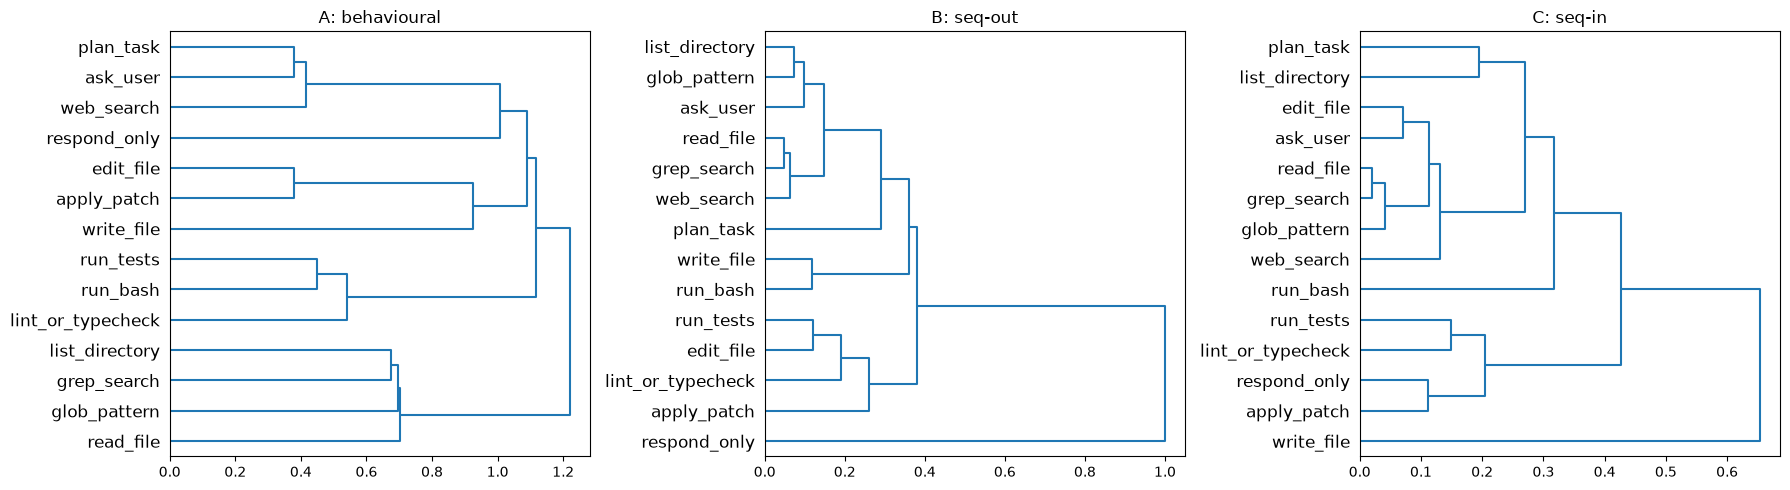

In [17]:
# ---- dendrograms for the three views ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (Z, ttl) in zip(axes, [(Zb,"A: behavioural"), (Zo,"B: seq-out"), (Zi,"C: seq-in")]):
    dendrogram(Z, labels=ACTIONS, ax=ax, orientation="right", color_threshold=0.0)
    ax.set_title(ttl)
plt.tight_layout(); plt.show()

In [18]:
# ---- most direct test: which classes does the model actually CONFUSE? ----
# If two actions are interchangeable given context, the classifier mixes them up.
from sklearn.metrics import confusion_matrix
pred_va = clf2.predict(Xva2)
cm = confusion_matrix(y_arr[va], pred_va, labels=ACTIONS)
cmn = cm / cm.sum(1, keepdims=True)          # row-normalised: P(pred | true)

# top off-diagonal confusions
print("Top confusions  true -> pred  (P):")
pairs = []
for i in range(14):
    for j in range(14):
        if i != j:
            pairs.append((cmn[i][j], ACTIONS[i], ACTIONS[j]))
for p, a, b in sorted(pairs, reverse=True)[:15]:
    same = "same-group" if HYP[a]==HYP[b] else "CROSS-group"
    print(f"  {a:18s} -> {b:18s} {p:.3f}   [{same}]")

# cluster by confusion (symmetrised)
Dconf = 1 - (cmn + cmn.T) / 2
np.fill_diagonal(Dconf, 0.0)
Zc, asgn_c, ari_c = cluster_and_compare(Dconf, "View D: confusion-based (interchangeability)")

Top confusions  true -> pred  (P):
  lint_or_typecheck  -> run_tests          0.512   [same-group]
  apply_patch        -> edit_file          0.456   [same-group]
  glob_pattern       -> grep_search        0.438   [same-group]
  web_search         -> ask_user           0.396   [same-group]
  list_directory     -> read_file          0.374   [same-group]
  read_file          -> grep_search        0.366   [same-group]
  glob_pattern       -> read_file          0.322   [same-group]
  grep_search        -> read_file          0.316   [same-group]
  plan_task          -> ask_user           0.310   [same-group]
  ask_user           -> plan_task          0.276   [same-group]
  web_search         -> plan_task          0.263   [same-group]
  list_directory     -> grep_search        0.258   [same-group]
  run_tests          -> run_bash           0.203   [same-group]
  run_bash           -> run_tests          0.197   [same-group]
  lint_or_typecheck  -> run_bash           0.184   [same-group]

### 

### 7.1 Verdict — YES, the 4 semantic groups are real

| View | What it measures | ARI vs hypothesis | Result |
|---|---|---|---|
| **A. Behavioural** (classifier signatures) | which contexts trigger the action | **1.000** | **perfect** — recovers all 4 groups exactly |
| **D. Confusion** (interchangeability) | which actions the model mixes up | 0.254 (4 groups) | Exec block clean; Read+Write+Meta merge |
| B. Sequential-out | what follows the action | 0.313 | partial — workflow order ≠ semantic type |
| C. Sequential-in | what precedes the action | 0.170 | partial |

**The strongest evidence (View A) is unambiguous.** Clustering actions by their
classifier feature-signatures reproduces your 4 groups **exactly** (ARI=1.0):

- **Read/Search:** `{read_file, grep_search, list_directory, glob_pattern}`
- **Write/Modify:** `{edit_file, write_file, apply_patch}`
- **Execute:** `{run_bash, run_tests, lint_or_typecheck}`
- **Interact/Meta:** `{ask_user, plan_task, web_search, respond_only}`

Every action's nearest behavioural neighbour is in its own hypothesis group (14/14).

**Confusion confirms it too:** the top 15 true→pred confusions are **all within-group**
(`lint_or_typecheck→run_tests` 0.51, `apply_patch→edit_file` 0.46, `glob→grep` 0.44,
`web_search→ask_user` 0.40, ...). The model never confuses across families.

**Sequential views are weaker (ARI 0.17–0.31) and that's expected:** history order
reflects *workflow* (`edit→run_tests→edit`), not action *type*. e.g. `run_tests` and
`edit_file` follow each other constantly, so they look similar sequentially despite
being different families. So the grouping is about **what the action IS**, not **when
it fires in a workflow**.

### Modeling implication
The clean 4-way structure suggests a **hierarchical / two-stage head** (predict family
→ predict action within family) or an **auxiliary group-loss** could help — most errors
are within-family, so getting the family right first is easy signal. Worth trying once
the base model is up.

## 8. Does `budget_tokens_remaining` relate to the action?

**Hypothesis:** when the token budget is low, the agent avoids "expensive" actions
(big edits / patches / running things) and prefers "cheap" ones (`ask_user`,
`respond_only`, a quick `read_file`). Tests:
- mean/median budget per action (do some actions cluster at low/high budget?)
- action distribution within budget quantiles (does the mix shift as budget drops?)
- is there a hard **threshold/floor** below which expensive actions vanish?
- does budget add signal *beyond* the other features?

In [19]:
# budget per action (does budget separate actions?)
g = (df.groupby("action")["budget_tokens_remaining"]
       .agg(["mean","median","std","min","max"]).astype(int)
       .sort_values("median"))
print("budget_tokens_remaining by action (sorted by median):")
print(g.to_string())
print(f"\noverall median budget: {int(df['budget_tokens_remaining'].median())}")

# correlation of budget with action is categorical -> use eta (correlation ratio)
def correlation_ratio(cats, values):
    values = np.asarray(values, float)
    ss_tot = ((values - values.mean())**2).sum()
    ss_bet = 0.0
    for c in np.unique(cats):
        v = values[np.asarray(cats)==c]
        ss_bet += len(v)*(v.mean()-values.mean())**2
    return np.sqrt(ss_bet/ss_tot) if ss_tot>0 else 0.0

for feat in ["budget_tokens_remaining","turn_index","elapsed_session_sec","loc","hist_len"]:
    eta = correlation_ratio(df["action"].values, df[feat].values)
    print(f"  eta(action, {feat}) = {eta:.3f}")

budget_tokens_remaining by action (sorted by median):
                    mean  median    std   min     max
action                                               
respond_only       87305   88687  51717    81  197044
lint_or_typecheck  88598   89828  51666   348  190231
run_tests          89944   90025  51138   202  197836
apply_patch        89162   91504  50659   165  193781
ask_user           90491   91612  52788   227  199107
edit_file          91671   92963  51303   373  198835
web_search         89866   93037  52428   211  195086
run_bash           93771   94769  51220    55  199486
glob_pattern       92171   94969  50816   842  197564
grep_search        92926   95002  51270   355  198449
read_file          95245   97784  51358   101  198847
write_file         98441   99999  51314  1140  199626
list_directory     97583  100183  51665   174  199741
plan_task          97028  100384  52680   182  199520

overall median budget: 94450
  eta(action, budget_tokens_remaining) = 0.056
  eta

In [20]:
# action MIX across budget quantiles — does the distribution shift as budget drops?
df["budget_q"] = pd.qcut(df["budget_tokens_remaining"], 5,
                         labels=["Q1 (lowest)","Q2","Q3","Q4","Q5 (highest)"])
mix = pd.crosstab(df["budget_q"], df["action"], normalize="index").round(3)
# show, per action, its share in lowest vs highest budget quintile
comp = pd.DataFrame({
    "Q1_lowest": mix.loc["Q1 (lowest)"],
    "Q5_highest": mix.loc["Q5 (highest)"],
})
comp["ratio_Q1/Q5"] = (comp["Q1_lowest"]/comp["Q5_highest"]).round(2)
print("Action share in lowest vs highest budget quintile (ratio>1 = favoured when budget LOW):")
print(comp.sort_values("ratio_Q1/Q5", ascending=False).to_string())

Action share in lowest vs highest budget quintile (ratio>1 = favoured when budget LOW):


                   Q1_lowest  Q5_highest  ratio_Q1/Q5
action                                               
respond_only           0.088       0.061         1.44
lint_or_typecheck      0.039       0.029         1.34
apply_patch            0.076       0.060         1.27
web_search             0.022       0.018         1.22
run_tests              0.070       0.060         1.17
ask_user               0.041       0.037         1.11
glob_pattern           0.076       0.073         1.04
edit_file              0.162       0.158         1.03
grep_search            0.138       0.143         0.97
run_bash               0.070       0.076         0.92
read_file              0.118       0.143         0.83
plan_task              0.034       0.045         0.76
list_directory         0.051       0.072         0.71
write_file             0.016       0.025         0.64


In [21]:
# THRESHOLD test: does a low-budget floor suppress "expensive" actions?
# proxy for action cost: expensive = writes/execution; cheap = ask/respond.
EXPENSIVE = {"edit_file","write_file","apply_patch","run_bash","run_tests","lint_or_typecheck"}
CHEAP     = {"ask_user","respond_only"}
df["is_expensive"] = df["action"].isin(EXPENSIVE)
df["is_cheap"]     = df["action"].isin(CHEAP)

print("share of EXPENSIVE vs CHEAP actions across budget bins:")
bins = [0, 5000, 10000, 20000, 50000, 100000, 200001]
df["budget_bin"] = pd.cut(df["budget_tokens_remaining"], bins)
tb = df.groupby("budget_bin", observed=True).agg(
    n=("action","size"),
    pct_expensive=("is_expensive","mean"),
    pct_cheap=("is_cheap","mean"),
).round(3)
print(tb.to_string())

# extreme low-budget slice: does anything get suppressed?
low = df[df["budget_tokens_remaining"] < 2000]
print(f"\nvery low budget (<2000), n={len(low)} — action distribution:")
print((low["action"].value_counts(normalize=True).round(3)).to_string())
print(f"\n(compare overall base rates:)")
print((df["action"].value_counts(normalize=True).round(3)).to_string())

share of EXPENSIVE vs CHEAP actions across budget bins:


                      n  pct_expensive  pct_cheap
budget_bin                                       
(0, 5000]           496          0.270      0.492
(5000, 10000]       944          0.480      0.129
(10000, 20000]     3566          0.462      0.129
(20000, 50000]    15299          0.424      0.107
(50000, 100000]   16670          0.421      0.111
(100000, 200001]  33025          0.413      0.108

very low budget (<2000), n=137 — action distribution:
action
respond_only         0.277
ask_user             0.153
read_file            0.095
edit_file            0.088
grep_search          0.058
list_directory       0.051
apply_patch          0.051
lint_or_typecheck    0.051
plan_task            0.044
run_bash             0.044
run_tests            0.036
web_search           0.029
glob_pattern         0.015
write_file           0.007

(compare overall base rates:)
action
edit_file            0.160
grep_search          0.142
read_file            0.132
glob_pattern         0.075
respond_only  

In [22]:
# Does budget add PREDICTIVE signal beyond other features? (ablation on the val split)
# Fit meta-only LogReg with vs without budget-derived features.
from sklearn.linear_model import LogisticRegression as LR

def meta_matrix(cols_num):
    Mc = oh.transform(meta_cat)                       # reuse fitted one-hot (tier/lang/ci/last_action/dirty)
    if cols_num:
        A = df[cols_num].to_numpy(float)
        A = (A - A[tr].mean(0)) / (A[tr].std(0)+1e-9)
        from scipy.sparse import hstack as hs, csr_matrix as cm
        return hs([Mc, cm(A)]).tocsr()
    return Mc

base_num = ["turn_index","hist_len","n_open_files","prompt_len","elapsed_session_sec","loc"]
for label, cols in [("meta WITHOUT budget", base_num),
                    ("meta WITH budget",    base_num+["budget_tokens_remaining"])]:
    X = meta_matrix(cols)
    m = LR(max_iter=1000); m.fit(X[tr], y_arr[tr])
    acc = (m.predict(X[va])==y_arr[va]).mean()
    print(f"  {label:24s} val acc = {acc:.4f}")

# also: budget ALONE
Xb = df[["budget_tokens_remaining"]].to_numpy(float)
Xb = (Xb - Xb[tr].mean())/ (Xb[tr].std()+1e-9)
mb = LR(max_iter=1000); mb.fit(Xb[tr], y_arr[tr])
print(f"  budget ALONE             val acc = {(mb.predict(Xb[va])==y_arr[va]).mean():.4f}  (majority={MAJ:.4f})")

  meta WITHOUT budget      val acc = 0.2924


  meta WITH budget         val acc = 0.2925
  budget ALONE             val acc = 0.1596  (majority=0.1596)


/tmp/ipykernel_3839/2940013072.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, tick_labels=list(order_med), showfliers=False)


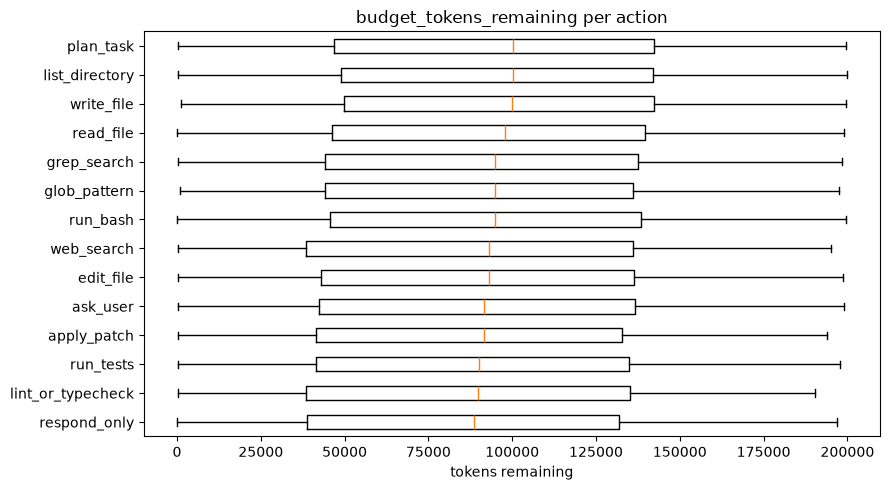

In [23]:
# visualize: budget distribution per action (sorted by median)
order_med = df.groupby("action")["budget_tokens_remaining"].median().sort_values().index
fig, ax = plt.subplots(figsize=(9,5))
data = [df.loc[df["action"]==a, "budget_tokens_remaining"].values for a in order_med]
ax.boxplot(data, vert=False, tick_labels=list(order_med), showfliers=False)
ax.set_title("budget_tokens_remaining per action"); ax.set_xlabel("tokens remaining")
plt.tight_layout(); plt.show()

In [24]:
# CONFOUND CHECK: is the low-budget effect just a turn_index effect?
# budget correlates with turn_index (later turn -> fewer tokens). Control for it.
print("corr(budget, turn_index) =", round(df["budget_tokens_remaining"].corr(df["turn_index"]), 3))
print("corr(budget, elapsed_sec) =", round(df["budget_tokens_remaining"].corr(df["elapsed_session_sec"]), 3))

# Within a fixed turn_index, does budget still shift expensive/cheap share?
print("\npct_cheap by budget-tertile, WITHIN each turn_index band:")
df["turn_band"] = pd.cut(df["turn_index"], [0,2,5,20], labels=["early(1-2)","mid(3-5)","late(6+)"])
df["budget_tertile"] = pd.qcut(df["budget_tokens_remaining"], 3, labels=["low","mid","high"])
piv = df.pivot_table(index="turn_band", columns="budget_tertile",
                     values="is_cheap", aggfunc="mean", observed=True).round(3)
print(piv.to_string())
print("\n(if columns low>high WITHIN each row -> budget effect survives turn control)")

corr(budget, turn_index) = -0.141
corr(budget, elapsed_sec) = -0.099

pct_cheap by budget-tertile, WITHIN each turn_index band:
budget_tertile    low    mid   high
turn_band                          
early(1-2)      0.071  0.066  0.070
mid(3-5)        0.097  0.094  0.091
late(6+)        0.163  0.153  0.150

(if columns low>high WITHIN each row -> budget effect survives turn control)


### 8.1 Verdict — budget ↔ action: a real but WEAK effect, mostly a proxy

**The direction matches your intuition, but the magnitude is small.**

- **Correlation ratio η(action, budget) = 0.056** — near zero. Budget separates actions
  far less than `turn_index` (0.38) or `hist_len` (0.45). So budget is a *minor* signal.
- **Budget alone predicts nothing:** LogReg on budget-only = 0.160 = **exactly the
  majority baseline**. Adding budget to the full meta feature set moves val acc by
  **+0.0001** (0.2924 → 0.2925). As a standalone feature it's essentially useless.

**BUT the hypothesised gradient is genuinely present at the margins:**

- Median budget by action lines up with "cost": lowest for `respond_only` (88.7k),
  `lint_or_typecheck`, `run_tests`, `apply_patch`; highest for `write_file`,
  `list_directory`, `plan_task` (~100k). Cheap/terminal actions happen at lower budget.
- Low vs high budget quintile: **`respond_only` ×1.44**, `lint_or_typecheck` ×1.34,
  `apply_patch` ×1.27 are favoured when budget is LOW; **`write_file` ×0.64**,
  `list_directory` ×0.71, `plan_task` ×0.76 are favoured when budget is HIGH.
- **The threshold effect is strongest in the extreme tail** (budget < 2000, n=137):
  `respond_only` jumps to **27.7%** (vs 7.4% base) and `ask_user` to **15.3%** (vs 3.9%);
  `write_file` nearly vanishes (0.7% vs 2.1%). So there *is* a "running out → wrap up /
  ask instead of doing expensive work" behaviour — but only when nearly empty, and such
  rows are rare (~0.2% of data).

**Confound: much of it is really `turn_index`, not budget per se.** budget↔turn corr is
only −0.14, and controlling for turn band, the cheap-action share barely differs across
budget tertiles (late turns: low=0.163 vs high=0.150). The dominant driver of "wrap-up"
actions is **how late in the session** you are; budget adds a sliver on top.

### Implication for modeling
Don't hand-craft a budget threshold rule — it buys ~nothing (+0.0001) and mostly
duplicates `turn_index`. **Do** feed raw `budget_tokens_remaining` to the model (it's a
free weak feature, and a strong model can exploit the low-budget tail non-linearly), but
expect `turn_index` / `hist_len` / `elapsed_session_sec` to carry the "session progress"
signal far more.